# Image Augmentation Workbench

This notebook creates a separate augmented dataset for the classification workshop.

We will:
- load the source images,
- inspect current class imbalance,
- preview realistic augmentations,
- generate extra images for smaller classes,
- export the result to a new folder with a metadata file.

The notebook respects the active training goal:
- `device_type` augments only the clean device folders used for training, then preserves the original `Defect` images as a held-out challenge set.
- `damage_status` augments both `Damaged` and `Not-Damaged` examples when class balancing calls for it. In that mode, augmented clean device images are valid extra `Not-Damaged` examples.


## 1. Imports and helpers

This notebook uses the same shared workshop utilities as the classification notebook so the workflow stays consistent.

In [10]:
from pathlib import Path
import shutil
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import (
    compute_balanced_targets,
    export_augmented_dataset,
    load_image_records,
    preview_augmentations,
    record_timing,
    target_column_for_mode,
    timing_frame,
    validate_target_mode,
)

step_timings = []

## 2. Configuration

Change these values to control where images come from and where augmented copies should be saved.

### Student change points

Try changing one setting at a time, then rerun the notebook from this cell downward and inspect the class-count plots and preview images.

- `TARGET_MODE`: switch between `damage_status` and `device_type`.
- `INCLUDED_DEVICE_TYPES`: choose which clean device folders are included.
- `TARGET_CLASS_SIZE`: change how many examples each class should have after augmentation.
- `OUTPUT_IMAGE_SIZE`: change the exported image size.
- `CLUSTERING_FOCUS_DEVICE` and `CLUSTERING_TARGET_CLASS_SIZE`: change the clustering-ready export.

After changing a value, ask: did the dataset become more balanced, more realistic, or accidentally less trustworthy?


In [11]:
# Student change point: update if your source dataset has a different name or location.
SOURCE_DATASET_ROOT = (NOTEBOOK_DIR.parent / "Device_Images_Nelson").resolve()
SOURCE_METADATA_PATH = SOURCE_DATASET_ROOT / "metadata.csv"
INCLUDED_DEVICE_TYPES = ["device1", "device 2"]  # Student change point: add/remove folders if they exist.
OUTPUT_IMAGE_SIZE = 100 # Student change point: smaller is faster; larger preserves more detail.
RANDOM_SEED = 42
########### ---------Classification Augmentation Configuration---------- ###########
TARGET_MODE = "device_type"  # Student change point: try "device_type" and compare which classes are balanced.
TARGET_CLASS_SIZE = 67  # Student change point: use None to match the largest class, or a number like 20/60.
OUTPUT_DATASET_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Device_Images").resolve()
############# ---------Clustering Augmentation Configuration ---------- ###########
CLUSTERING_OUTPUT_DATASET_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Defect_Localization_Images").resolve()
CREATE_CLUSTERING_EXPORT = True  # Student change point: set False to skip the clustering-ready export.
CLUSTERING_FOCUS_DEVICE = "device 3"  # Student change point: choose which device gets a clean reference set.
CLUSTERING_TARGET_CLASS_SIZE = 1  # Student change point: larger values create more augmented localization images.



print(f"Source dataset: {SOURCE_DATASET_ROOT}")
print(f"Output dataset: {OUTPUT_DATASET_ROOT}")
print(f"Clustering output dataset: {CLUSTERING_OUTPUT_DATASET_ROOT}")
print(f"Target mode: {TARGET_MODE}")
print(f"Included device folders: {INCLUDED_DEVICE_TYPES}")
print(f"Create clustering export: {CREATE_CLUSTERING_EXPORT}")


Source dataset: C:\Users\k-12outreach\Summercamp_ShoRydberg\Summer_Workshop_ShoRydberg\Device_Images_Nelson
Output dataset: C:\Users\k-12outreach\Summercamp_ShoRydberg\Summer_Workshop_ShoRydberg\Augmented_Device_Images
Clustering output dataset: C:\Users\k-12outreach\Summercamp_ShoRydberg\Summer_Workshop_ShoRydberg\Augmented_Defect_Localization_Images
Target mode: device_type
Included device folders: ['device1', 'device 2']
Create clustering export: True


## 3. Load source records and inspect imbalance

Before generating data, we should measure the problem we are trying to solve.


Loaded 60 records in 0.02 seconds before workshop filtering
Standard device records after included-device filtering: 8
Defect records available: 10
Clustering clean records for device 3: 25
Clustering export records before augmentation: 35
Defect images are excluded from augmentation so they cannot leak into device-type training.


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge
0,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
1,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
2,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/2.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
3,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/2_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
4,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/3.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False


Target `device_type` is ready with classes: ['device 2', 'device1']


,count
device_type,
device 2,6
device1,2


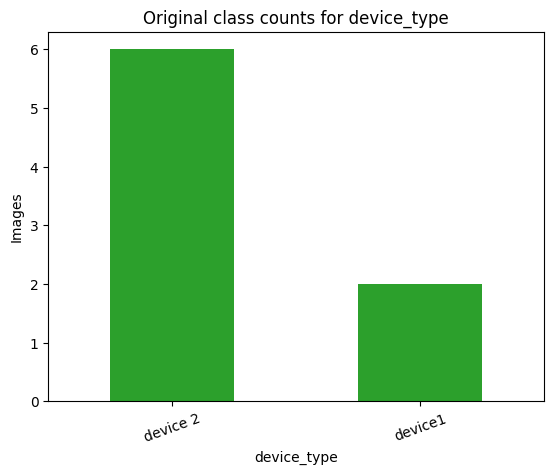

In [12]:
started = time.perf_counter()
all_records = load_image_records(
    SOURCE_DATASET_ROOT,
    metadata_path=SOURCE_METADATA_PATH if SOURCE_METADATA_PATH.exists() else None,
)
scan_elapsed = record_timing(step_timings, "dataset_scan", started)

print(f"Loaded {len(all_records)} records in {scan_elapsed:.2f} seconds before workshop filtering")

standard_device_records = all_records[all_records["is_standard_device_image"]].reset_index(drop=True)
standard_device_records = standard_device_records[standard_device_records["device_type"].isin(INCLUDED_DEVICE_TYPES)].reset_index(drop=True)
defect_records = all_records[all_records["is_defect_challenge"]].reset_index(drop=True)
clustering_clean_records = all_records[
    all_records["is_standard_device_image"] & (all_records["device_type"] == CLUSTERING_FOCUS_DEVICE)
].reset_index(drop=True)
clustering_records = pd.concat([clustering_clean_records, defect_records], ignore_index=True)

print(f"Standard device records after included-device filtering: {len(standard_device_records)}")
print(f"Defect records available: {len(defect_records)}")
print(f"Clustering clean records for {CLUSTERING_FOCUS_DEVICE}: {len(clustering_clean_records)}")
print(f"Clustering export records before augmentation: {len(clustering_records)}")

if TARGET_MODE == "device_type":
    records = standard_device_records.copy()
    print("Defect images are excluded from augmentation so they cannot leak into device-type training.")
else:
    records = pd.concat([standard_device_records, defect_records], ignore_index=True)
    print("Damage-status note: augmented clean device images will serve as extra `Not-Damaged` samples.")

display(records.head())

is_valid_target, target_message = validate_target_mode(records, TARGET_MODE)
print(target_message)
if not is_valid_target:
    raise ValueError(target_message)

target_column = target_column_for_mode(TARGET_MODE)
records = records[records[target_column].notna()].reset_index(drop=True)
class_counts = records[target_column].value_counts(dropna=True).sort_index()
display(class_counts.rename("count").to_frame())
class_counts.plot(kind="bar", color="#2ca02c", title=f"Original class counts for {TARGET_MODE}")
plt.ylabel("Images")
plt.xticks(rotation=20)
plt.show()


## 4. Preview augmentation ideas

We want realistic variation, not nonsense. Use this preview to judge whether the transformations still look believable for your inspection task.

Pay special attention to the rotation examples. Rotating a rectangular image creates empty corner pixels because the image no longer lines up perfectly with the square frame. If those empty pixels are filled with black, the result can look like a black border or shadow. The preview crops dark augmentation edges so the generated examples do not keep artificial black bands.

### Why rotation can create dark edges

Think of rotating a printed photo on top of a square table. After you turn the photo, the table corners are exposed. Image software has the same problem: it must invent pixels for the newly exposed corners.

A black shadow appears when those invented pixels are black. Bicubic resizing can also blend the black pixels with nearby real pixels, which makes the edge look like a soft shadow instead of a clean border.

This notebook mitigates that in two ways:
- it uses black only as a temporary marker for pixels introduced by augmentation,
- it trims those dark edge bands when they appear around the outside,
- it center-crops the rotated image slightly, then resizes it back to the normal size.

Cropping is a tradeoff. It removes suspicious borders, but it zooms in a little. For defect images, that is usually better than teaching a model or clustering method to notice artificial black corners.

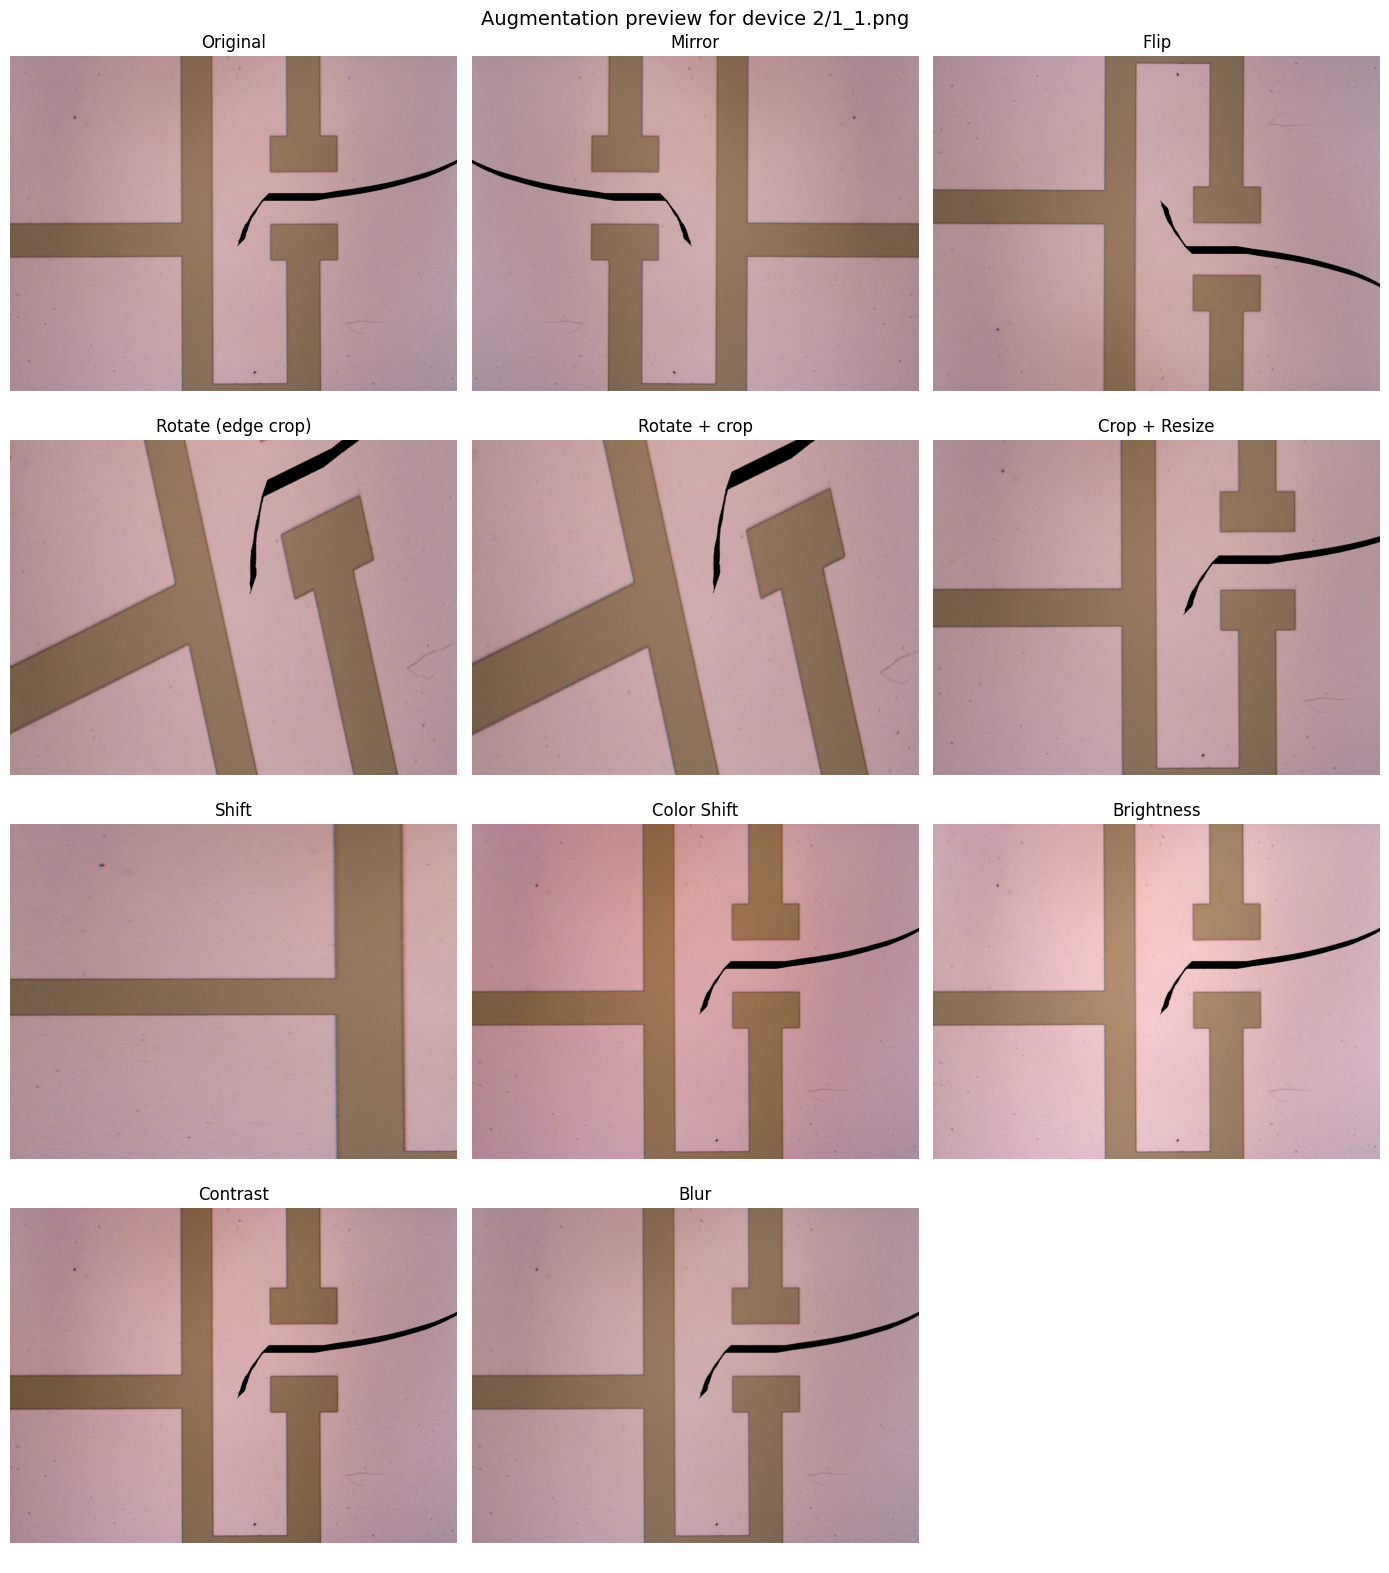

In [13]:
preview_row = records.sample(1, random_state=RANDOM_SEED).iloc[0]
with Image.open(preview_row["filepath"]) as image:
    preview_images = preview_augmentations(image, seed=RANDOM_SEED)

preview_items = list(preview_images.items())
columns = 3
rows = (len(preview_items) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(14, 4 * rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax in axes:
    ax.axis("off")

for ax, (title, aug_image) in zip(axes, preview_items):
    ax.imshow(aug_image)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"Augmentation preview for {preview_row['relative_path']}", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Decide how many new images to create

By default, this notebook balances the classes by adding more images to the smaller classes.
In `damage_status` mode, this plan is a binary-class plan: extra clean device images count only toward `Not-Damaged`, and extra defect images count toward `Damaged`.


In [14]:
augmentation_plan = compute_balanced_targets(
    records,
    label_column=target_column,
    target_class_size=TARGET_CLASS_SIZE,
)
plan_frame = pd.DataFrame(
    {
        "current_count": class_counts,
        "new_images_needed": pd.Series(augmentation_plan),
    }
).fillna(0).astype(int)
plan_frame["projected_total"] = plan_frame["current_count"] + plan_frame["new_images_needed"]
display(plan_frame)

if TARGET_MODE == "damage_status":
    print("Damage-status augmentation check:")
    print("`Not-Damaged` includes clean device images from the included device folders.")
    print("`Damaged` includes defect images from the `Defect` folder.")
    display(plan_frame.loc[[label for label in ["Damaged", "Not-Damaged"] if label in plan_frame.index]])


,current_count,new_images_needed,projected_total
device 2,6,61,67
device1,2,65,67


## 6. Export the augmented dataset

This cell may take a while. Watch the progress bar and status text. The notebook should show active progress while images are being copied and generated.

The exported images use the safer rotation behavior from the preview: rotate, trim dark edge bands when they appear, crop slightly, and resize. This keeps rotation useful without adding obvious black artifacts.

In `device_type` mode, the original `Defect` images are copied through after augmentation so the classification notebooks still have a held-out defect challenge set.


In [15]:
started = time.perf_counter()
exported_records = export_augmented_dataset(
    records,
    output_root=OUTPUT_DATASET_ROOT,
    label_column=target_column,
    target_class_size=TARGET_CLASS_SIZE,
    seed=RANDOM_SEED,
    out_size=OUTPUT_IMAGE_SIZE,
    status_prefix="Augment",
)
export_elapsed = record_timing(step_timings, "augmentation_export", started)

if TARGET_MODE == "device_type" and not defect_records.empty:
    # Preserve the original defect images as a held-out challenge set.
    # They are copied after augmentation so they are not balanced or augmented.
    preserved_defect_records = defect_records.copy()
    preserved_defect_records["is_augmented"] = False
    preserved_defect_records["source_relative_path"] = preserved_defect_records["relative_path"]

    for row in preserved_defect_records.itertuples(index=False):
        source_path = Path(row.filepath)
        export_path = OUTPUT_DATASET_ROOT / Path(row.relative_path)
        export_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_path, export_path)

    preserved_defect_records["filepath"] = preserved_defect_records["relative_path"].apply(
        lambda value: str(OUTPUT_DATASET_ROOT / Path(value))
    )
    exported_records = pd.concat([exported_records, preserved_defect_records], ignore_index=True, sort=False)
    exported_records.to_csv(OUTPUT_DATASET_ROOT / "metadata.csv", index=False)

print(f"Augmented dataset exported in {export_elapsed:.2f} seconds")
print(f"Metadata written to: {OUTPUT_DATASET_ROOT / 'metadata.csv'}")
if TARGET_MODE == "device_type":
    preserved_defect_rows = int(exported_records["is_defect_challenge"].fillna(False).sum())
    augmented_defect_rows = int(
        (exported_records["is_defect_challenge"].fillna(False) & exported_records["is_augmented"].fillna(False)).sum()
    )
    print(f"Original defect challenge rows preserved: {preserved_defect_rows}")
    print(f"Augmented defect rows exported for device_type mode: {augmented_defect_rows}")
display(exported_records.head())

Augmented dataset exported in 66.28 seconds
Metadata written to: C:\Users\k-12outreach\Summercamp_ShoRydberg\Summer_Workshop_ShoRydberg\Augmented_Device_Images\metadata.csv
Original defect challenge rows preserved: 10
Augmented defect rows exported for device_type mode: 0


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge,is_augmented,source_relative_path
0,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/1.png
1,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/1_1.png
2,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/2.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/2.png
3,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/2_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/2_1.png
4,C:\Users\k-12outreach\Summercamp_ShoRydberg\Su...,device 2/3.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/3.png


## 7. Export the clustering-ready dataset

The clustering notebook prefers `Augmented_Defect_Localization_Images` when that folder has a metadata file. This export keeps that folder fresh using the same crop-only augmentation behavior, so stale black-border images do not survive from older runs.


In [16]:
clustering_exported_records = pd.DataFrame()

if CREATE_CLUSTERING_EXPORT:
    if clustering_clean_records.empty:
        raise ValueError(f"No clean records found for clustering focus device `{CLUSTERING_FOCUS_DEVICE}`.")
    if defect_records.empty:
        raise ValueError("No defect records found for clustering export.")

    started = time.perf_counter()
    clustering_exported_records = export_augmented_dataset(
        clustering_records,
        output_root=CLUSTERING_OUTPUT_DATASET_ROOT,
        label_column="damage_status",
        target_class_size=CLUSTERING_TARGET_CLASS_SIZE,
        seed=RANDOM_SEED,
        out_size=OUTPUT_IMAGE_SIZE,
        status_prefix="Augment clustering",
    )
    clustering_export_elapsed = record_timing(step_timings, "clustering_augmentation_export", started)

    print(f"Clustering-ready dataset exported in {clustering_export_elapsed:.2f} seconds")
    print(f"Metadata written to: {CLUSTERING_OUTPUT_DATASET_ROOT / 'metadata.csv'}")
    display(clustering_exported_records["damage_status"].value_counts(dropna=True).sort_index().rename("count").to_frame())
else:
    print("Skipped clustering export because CREATE_CLUSTERING_EXPORT is False.")


Clustering-ready dataset exported in 0.45 seconds
Metadata written to: C:\Users\k-12outreach\Summercamp_ShoRydberg\Summer_Workshop_ShoRydberg\Augmented_Defect_Localization_Images\metadata.csv


,count
damage_status,
Damaged,10
Not-Damaged,25


## 8. Verify the result

We should always confirm that the export actually improved class balance and preserved label information.


,before_export,after_export,added
device_type,,,
device 2,6,67,61
device1,2,67,65


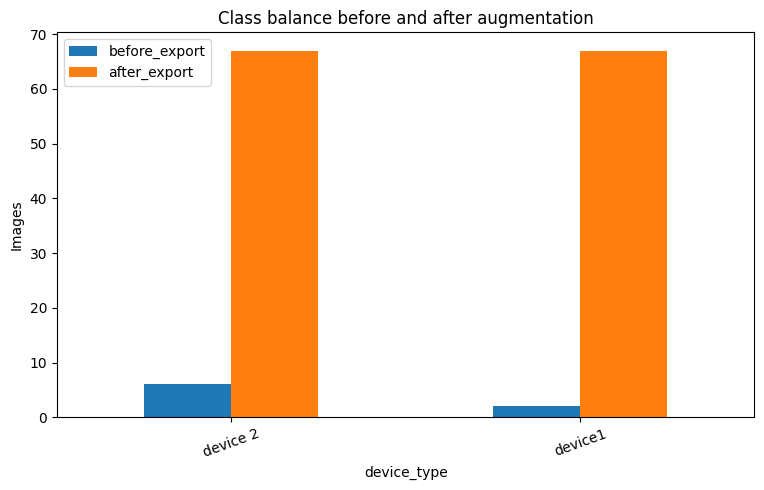

Verified: original defect images were preserved as challenge-only rows.
Verified: no defect images were augmented for the device_type training dataset.


In [17]:
if TARGET_MODE == "device_type":
    exported_training_records = exported_records[exported_records["is_standard_device_image"].fillna(False)].copy()
else:
    exported_training_records = exported_records.copy()

post_counts = exported_training_records[target_column].value_counts(dropna=True).sort_index()
verification = pd.DataFrame(
    {
        "before_export": class_counts,
        "after_export": post_counts,
    }
).fillna(0).astype(int)
verification["added"] = verification["after_export"] - verification["before_export"]
display(verification)

verification[["before_export", "after_export"]].plot(kind="bar", figsize=(9, 5), title="Class balance before and after augmentation")
plt.ylabel("Images")
plt.xticks(rotation=20)
plt.show()

if TARGET_MODE == "device_type":
    preserved_defect_rows = int(exported_records["is_defect_challenge"].fillna(False).sum())
    augmented_defect_rows = int(
        (exported_records["is_defect_challenge"].fillna(False) & exported_records["is_augmented"].fillna(False)).sum()
    )
    if len(defect_records) > 0 and preserved_defect_rows != len(defect_records):
        raise ValueError(
            f"Expected {len(defect_records)} preserved defect challenge rows, found {preserved_defect_rows}."
        )
    if augmented_defect_rows != 0:
        raise ValueError(f"Expected zero augmented defect rows in device_type export, found {augmented_defect_rows}.")
    print("Verified: original defect images were preserved as challenge-only rows.")
    print("Verified: no defect images were augmented for the device_type training dataset.")
else:
    damage_counts = exported_records["damage_status"].value_counts(dropna=True).sort_index()
    print("Damage-status labels in exported dataset:")
    display(damage_counts.rename("count").to_frame())
    print("Verification note: augmented clean device images remain valid `Not-Damaged` samples in the exported binary dataset.")


## 8. Runtime summary

Runtime tracking helps students know the notebook is active and also shows which steps cost the most time.

In [18]:
runtime_table = timing_frame(step_timings)
display(runtime_table)

,step,seconds
0,dataset_scan,0.019
1,augmentation_export,66.276
2,clustering_augmentation_export,0.451


## 9. Next step

This export also excludes `device 3` by default, so it stays consistent with the classification notebook.

Point the classification notebook to `OUTPUT_DATASET_ROOT` when you want to train on the larger exported dataset.
If you switch that notebook to `TARGET_MODE = "damage_status"`, the augmented clean device images will be used as extra `Not-Damaged` examples.
